In [1]:
from aniposelib.cameras import CameraGroup, Camera
import numpy as np
import h5py
import glob
import os

In [23]:
# load 2d coords

# path
rootdir = '/Volumes/THANH/IceSkating/2d_coords/'
# rootdir = r'\\tsclient\thesis'
video_files = sorted(glob.glob(os.path.join(rootdir, 'cam*.h5')))

data = {}
for video_file in video_files:
    with h5py.File(video_file,'r') as f:
        data[video_file] = {
            "kpts" : f["kpts"][:],
        }

In [24]:
data[video_file]['kpts']

array([[1201.19128418, 1200.81481934, 1198.20129395, ...,  399.29559326,
         439.17779541,  447.75012207],
       [1196.40710449, 1196.34484863, 1193.38952637, ...,  400.87017822,
         440.32183838,  448.30957031],
       [1193.27209473, 1193.05273438, 1190.23950195, ...,  404.29486084,
         443.41619873,  449.92700195],
       ...,
       [1346.97619629, 1349.14404297, 1348.1661377 , ...,  396.090271  ,
         432.24249268,  433.80578613],
       [1342.83349609, 1344.91625977, 1343.7076416 , ...,  401.98297119,
         434.48547363,  432.06732178],
       [1338.21459961, 1340.47277832, 1338.68505859, ...,  401.45373535,
         432.79602051,  430.77325439]], shape=(4200, 34))

In [25]:
cam_keys = data.keys()
coords = []
for i,cam in enumerate(cam_keys):
    arr = data[cam]['kpts'].reshape(4200,17,2,order='F')
    coords.append(arr)
coords # (3,4200,17,2)
n_frames = coords[0].shape[0]
n_joints = coords[0].shape[1]

In [26]:
coords[0][1,:,:]

array([[824.57592773, 263.1897583 ],
       [827.60699463, 258.70343018],
       [825.34991455, 259.31292725],
       [839.5446167 , 259.37225342],
       [834.03704834, 259.90039062],
       [848.47351074, 279.9307251 ],
       [834.44042969, 281.92462158],
       [839.21429443, 303.63439941],
       [834.90057373, 312.21905518],
       [834.40911865, 297.29327393],
       [836.38677979, 335.12890625],
       [854.84777832, 334.23297119],
       [840.90130615, 333.81903076],
       [852.67346191, 382.60827637],
       [845.45526123, 382.63781738],
       [852.76898193, 431.00073242],
       [852.0982666 , 427.17285156]])

Camera 0: grabbed frame 200, shape: (1080, 1920, 3)
Camera 1: grabbed frame 200, shape: (1080, 1920, 3)
Camera 2: grabbed frame 200, shape: (1080, 1920, 3)


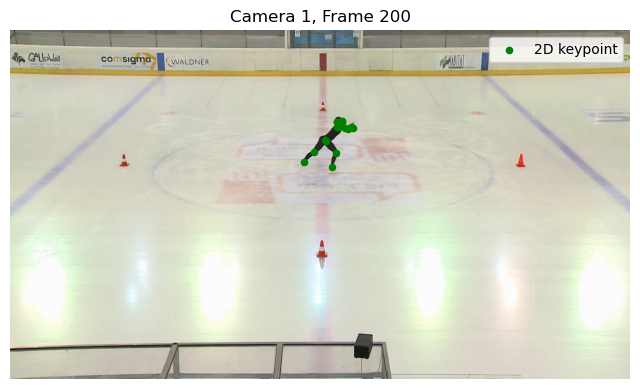

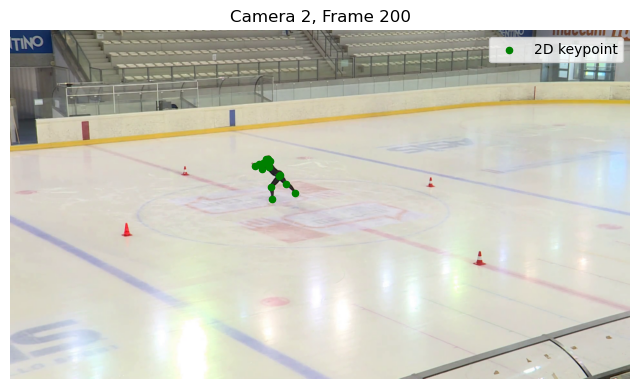

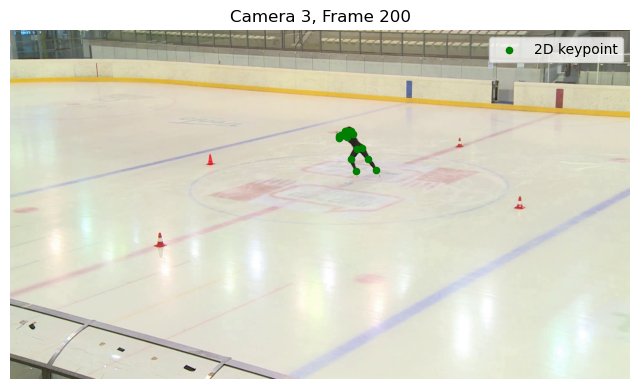

In [27]:
# reproject on frame 100th 
import cv2
import matplotlib.pyplot as plt 

path = '/Volumes/THANH/IceSkating/experiment/stimuli'
# path = r"\\cimec-storage6.cimec.unitn.it\ingdev\projects\THANH\IceSkating\experiment\stimuli"
video_files = sorted(glob.glob(os.path.join(path, '*.mp4')))

frame_idx = 200
frames_sample = []


for i, video_file in enumerate(video_files):
        cap = cv2.VideoCapture(video_file)
        
        # Set to the desired frame index
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        
        ret, frame = cap.read()
        if not ret:
            print(f"Failed to read frame {frame_idx} from camera {i}")
            frame = None
        frames_sample.append(frame)  # store the frame
        
        cap.release()
        if frame is not None:
            print(f"Camera {i}: grabbed frame {frame_idx}, shape: {frame.shape}")
for cam_idx in range(3):
        frame = frames_sample[cam_idx]
        if frame is None:
            continue
        
        plt.figure(figsize=(8,6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        
        for j in range(17):
            # original 2D keypoint
            x2d = coords[cam_idx][frame_idx, j, :]
            plt.scatter(x2d[0], x2d[1], c='g', s=20, label='2D keypoint' if j==0 else "")
            # # reproject using anipose camera
            # X3d = points_3d[frame_idx, j, :]
            # if np.any(np.isnan(X3d)):
            #     continue
            
            # x_proj = cgroup.cameras[cam_idx].project(X3d.reshape(1, 3)).flatten()
            # plt.scatter(x_proj[0], x_proj[1], c='r', s=50, marker='x', label='Reprojected 3D' if j==0 else "")

        plt.title(f"Camera {cam_idx+1}, Frame {frame_idx}")
        plt.legend(loc='upper right')
        plt.axis('off')
        plt.show()


In [21]:
path = r"\\cimec-storage6.cimec.unitn.it\ingdev\projects\THANH\IceSkating\experiment\stimuli"
video_files = sorted(glob.glob(os.path.join(path, '*.mp4')))
video_files

['\\\\cimec-storage6.cimec.unitn.it\\ingdev\\projects\\THANH\\IceSkating\\experiment\\stimuli\\cam1_big_chunk_1_small_chunk_1.mp4',
 '\\\\cimec-storage6.cimec.unitn.it\\ingdev\\projects\\THANH\\IceSkating\\experiment\\stimuli\\cam2_big_chunk_1_small_chunk_1.mp4',
 '\\\\cimec-storage6.cimec.unitn.it\\ingdev\\projects\\THANH\\IceSkating\\experiment\\stimuli\\cam3_big_chunk_1_small_chunk_1.mp4']

In [39]:
points_3d_clean[2142,:,:]

array([[ -0.73124287,  -0.94187258,   6.05622115],
       [ -0.74364324,  -0.96963007,   6.05615982],
       [ -0.73619423,  -0.9689513 ,   6.06246918],
       [ -0.6766855 ,  -1.01852126,   5.99291833],
       [ -0.66894796,  -1.01848904,   6.08074595],
       [ -0.55537136,  -0.9818048 ,   5.95662807],
       [ -0.55239   ,  -0.97570003,   6.11971599],
       [  2.21878966,  -1.4420712 ,   2.15874517],
       [ -0.76254857,  -0.83705825,   6.06374281],
       [  5.59295927,  -0.55553123, -23.1638446 ],
       [ -0.96126302,  -0.72454105,   6.03790203],
       [ -0.06490893,  -0.85942967,   6.04237087],
       [ -0.09638837,  -0.86103769,   6.16969768],
       [  0.04442677,  -0.5234927 ,   6.14641211],
       [ -0.17423346,  -0.54629265,   6.15515238],
       [  0.1330875 ,  -0.46608062,   6.15843173],
       [ -0.03325861,  -0.29599836,   6.23115277]])

In [60]:
import cv2
import numpy as np
import glob
import os

# path
path = '/Volumes/THANH/IceSkating/experiment/stimuli'
# path = r"\\cimec-storage6.cimec.unitn.it\ingdev\projects\THANH\IceSkating\experiment\stimuli"
video_files = sorted(glob.glob(os.path.join(path, '*.mp4')))

# COCO skeleton connections
skeleton = [[0,1],[0,2],[1,3],[2,4],[5,6],[5,7],[7,9],[6,8],[8,10],
            [11,12],[11,13],[13,15],[12,14],[14,16],[5,11],[6,12]]

# Open videos
caps = [cv2.VideoCapture(v) for v in video_files]

# Get video properties from first camera
fps = caps[0].get(cv2.CAP_PROP_FPS)
width = int(caps[0].get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(caps[0].get(cv2.CAP_PROP_FRAME_HEIGHT))
num_frames = int(caps[0].get(cv2.CAP_PROP_FRAME_COUNT))

# Create video writers (one per camera)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writers = []
for cam_idx in range(3):
    out_path = f"cam_{cam_idx+1}_anipose_reprojection_chunk2.mp4"
    writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))
    writers.append(writer)

# -------- MAIN LOOP --------
for frame_idx in range(8450):

    frames = []

    # Read synchronized frames
    for cap in caps:
        # cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)  # ← add this
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)

    if len(frames) != 3:
        break

    # Process each camera
    for cam_idx in range(3):

        frame = frames[cam_idx]

        # -------- Draw skeleton connections (reprojected 3D) --------
        for conn in skeleton:
            j1, j2 = conn
            p1 = points_3d_clean[frame_idx, j1, :]
            p2 = points_3d_clean[frame_idx, j2, :]
            if np.any(np.isnan(p1)) or np.any(np.isnan(p2)):
                continue
            x1 = cgroup.cameras[cam_idx].project(p1.reshape(1, 3)).flatten()
            x2 = cgroup.cameras[cam_idx].project(p2.reshape(1, 3)).flatten()
            cv2.line(frame,
                     (int(x1[0]), int(x1[1])),
                     (int(x2[0]), int(x2[1])),
                     (0, 255, 255), 1)  # yellow

        for j in range(17):

            # -------- Draw original 2D keypoints --------
            # x2d = kpts[cam_idx][frame_idx, j, :]
            # if not np.any(np.isnan(x2d)):
            #     cv2.circle(frame,
            #                (int(x2d[0]), int(x2d[1])),
            #                4,
            #                (0, 255, 0),  # green
            #                -1)

            # -------- Reproject 3D --------
            X3d = points_3d_clean[frame_idx, j, :]
            if np.any(np.isnan(X3d)):
                continue

            x_proj = cgroup.cameras[cam_idx].project(X3d.reshape(1, 3)).flatten()
            cv2.drawMarker(frame,
                           (int(x_proj[0]), int(x_proj[1])),
                           (0, 0, 255),  # red
                           markerType=cv2.MARKER_CROSS,
                           markerSize=12,
                           thickness=2)

        # -------- Frame number overlay --------
        cv2.putText(frame, f'Frame {frame_idx}', (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        # Write modified frame
        writers[cam_idx].write(frame)

    print(f"Processed frame {frame_idx}/{num_frames}", end="\r")

# Cleanup
for cap in caps:
    cap.release()
for writer in writers:
    writer.release()

print("\nDone.")

[h264 @ 0x7faf1af8fa80] Invalid NAL unit size (9742 > 199).
[h264 @ 0x7faf1af8fa80] missing picture in access unit with size 203
[h264 @ 0x7faf3b84a040] Invalid NAL unit size (9742 > 199).
[h264 @ 0x7faf3b84a040] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x7faf3b848d80] stream 1, offset 0x1b581cf: partial file
[h264 @ 0x7faf08308c00] Invalid NAL unit size (3441 > 3371).
[h264 @ 0x7faf08308c00] missing picture in access unit with size 3375
[h264 @ 0x7faf08319ec0] Invalid NAL unit size (3441 > 3371).
[h264 @ 0x7faf08319ec0] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x7faeedf10800] stream 0, offset 0x1cb3547: partial file


[h264 @ 0x7faeedf3c280] Invalid NAL unit size (9000 > 4949).
[h264 @ 0x7faeedf3c280] missing picture in access unit with size 4953
[h264 @ 0x7faeedf67780] Invalid NAL unit size (9000 > 4949).
[h264 @ 0x7faeedf67780] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x7faeedf3b900] stream 1, offset 0x18422a4: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x7faf3b848d80] stream 0, offset 0x1b58350: partial file


Processed frame 4670/8450
Done.


In [57]:
print(points_3d_clean[6000, :, :])

[[ 1.87564418 -1.33237424 -0.81597741]
 [ 1.87357487 -1.36072257 -0.83866234]
 [ 1.89750786 -1.36281029 -0.81381638]
 [ 1.89945307 -1.33766652 -0.8981809 ]
 [ 2.01944267 -1.34472796 -0.84567974]
 [ 1.85149902 -1.16732545 -0.91955737]
 [ 2.12890263 -1.1961797  -0.92059003]
 [ 1.74510352 -0.97160252 -0.98080219]
 [ 2.27509238 -1.01902162 -0.90569682]
 [ 1.63778436 -0.77400003 -0.97059451]
 [ 2.33755035 -0.87544737 -0.79241953]
 [ 1.94056469 -0.78989812 -1.17216315]
 [ 2.13737257 -0.79817479 -1.17073205]
 [ 1.78441664 -0.44996237 -1.22499597]
 [ 2.2656607  -0.47071994 -1.03493575]
 [ 1.65966191 -0.23884941 -1.57561048]
 [ 2.28207969 -0.16028433 -1.27788381]]


In [58]:
print("X range:", np.min(points_3d_clean[:,:,0]), np.max(points_3d_clean[:,:,0]))
print("Y range:", np.min(points_3d_clean[:,:,1]), np.max(points_3d_clean[:,:,1]))
print("Z range:", np.min(points_3d_clean[:,:,2]), np.max(points_3d_clean[:,:,2]))

X range: -5.335516394093752 7.400016685361171
Y range: -2.6364712241397896 -0.08205290613351832
Z range: -34.52922380608782 11.415120969557229


Done


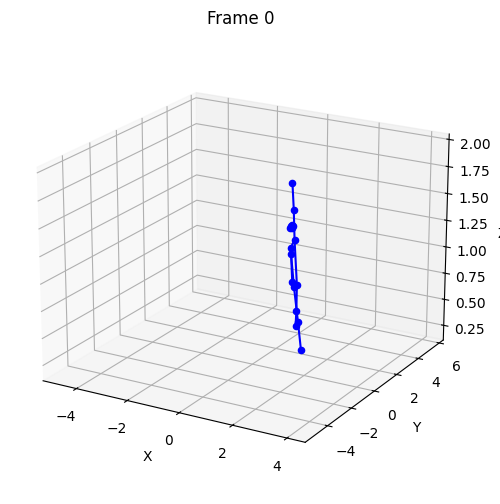

In [18]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D

# COCO skeleton connections [joint_a, joint_b]
SKELETON = [
    [0, 1], [0, 2],           # nose to eyes
    [1, 3], [2, 4],           # eyes to ears
    [5, 6],                   # shoulders
    [5, 7], [7, 9],           # left arm
    [6, 8], [8, 10],          # right arm
    [5, 11], [6, 12],         # shoulders to hips
    [11, 12],                 # hips
    [11, 13], [13, 15],       # left leg
    [12, 14], [14, 16],       # right leg
]
points_subset = points_3d_clean[5349:8450]  # shape: (8450-5329, n_joints, 3)
points_vis = np.stack([
    points_subset[..., 0],
    points_subset[..., 2],
   -points_subset[..., 1]
], axis=-1)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

def update(frame_idx):
    ax.cla()

    joints = points_vis[frame_idx]   

    # axis limits from transformed data
    ax.set_xlim(np.nanmin(points_vis[...,0]), np.nanmax(points_vis[...,0]))
    ax.set_ylim(np.nanmin(points_vis[...,1]), np.nanmax(points_vis[...,1]))
    ax.set_zlim(np.nanmin(points_vis[...,2]), np.nanmax(points_vis[...,2]))

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Frame {frame_idx}')
    ax.view_init(elev=20, azim=-60)
    # draw joints
    for j in range(17):
        if not np.any(np.isnan(joints[j])):
            ax.scatter(joints[j,0], joints[j,1], joints[j,2],
                       c='blue', s=20)

    # draw bones
    for a, b in SKELETON:
        if not np.any(np.isnan(joints[a])) and not np.any(np.isnan(joints[b])):
            ax.plot([joints[a,0], joints[b,0]],
                    [joints[a,1], joints[b,1]],
                    [joints[a,2], joints[b,2]],
                    'b-', linewidth=1.5)
            
ani = animation.FuncAnimation(
    fig, update,  # subtract start index
    frames=range(len(points_vis)),
    interval=20
)
ani.save('skeleton.mp4', writer='ffmpeg', fps=50, dpi=100)
print("Done")